In [61]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [62]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

In [63]:
NUTS2 = 'Thrace'
YEAR = '2024'

In [64]:
df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)

C:\Users\dimit\AppData\Local\Temp\ipykernel_26060\2622664866.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)


In [65]:
df.head()

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,23.65882,41.33542,0,2024-07-02,EL51,2024,7,2024-07-01,41.333732,23.659379,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,2024-07-02,41.333732,23.659379,14692.0,14711.0,2024-06-02,41.350189,23.650108,2024-07-01,2024-06-02,0.0
1,23.65882,41.33542,0,2024-07-03,EL51,2024,7,2024-07-01,41.333732,23.659379,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,2024-07-03,41.333732,23.659379,14745.0,14365.0,2024-06-02,41.350189,23.650108,2024-07-02,2024-06-02,0.0
2,23.65882,41.33542,0,2024-07-04,EL51,2024,7,2024-07-01,41.333732,23.659379,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,2024-07-04,41.333732,23.659379,14745.0,14330.0,2024-06-02,41.350189,23.650108,2024-07-03,2024-06-02,0.0
3,23.65882,41.33542,0,2024-07-05,EL51,2024,7,2024-07-01,41.333732,23.659379,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,2024-07-05,41.333732,23.659379,14845.0,14341.0,2024-06-02,41.350189,23.650108,2024-07-04,2024-06-02,0.0
4,23.65882,41.33542,0,2024-07-06,EL51,2024,7,2024-07-06,41.333732,23.659379,0.673732,0.254694,-0.571299,-0.254694,0.680970,0.274279,-0.577182,-0.274279,0.079766,0.062001,0.057825,0.062001,2024-07-06,41.333732,23.659379,14955.0,14534.0,2024-06-02,41.350189,23.650108,2024-07-05,2024-06-02,0.0


<Axes: >

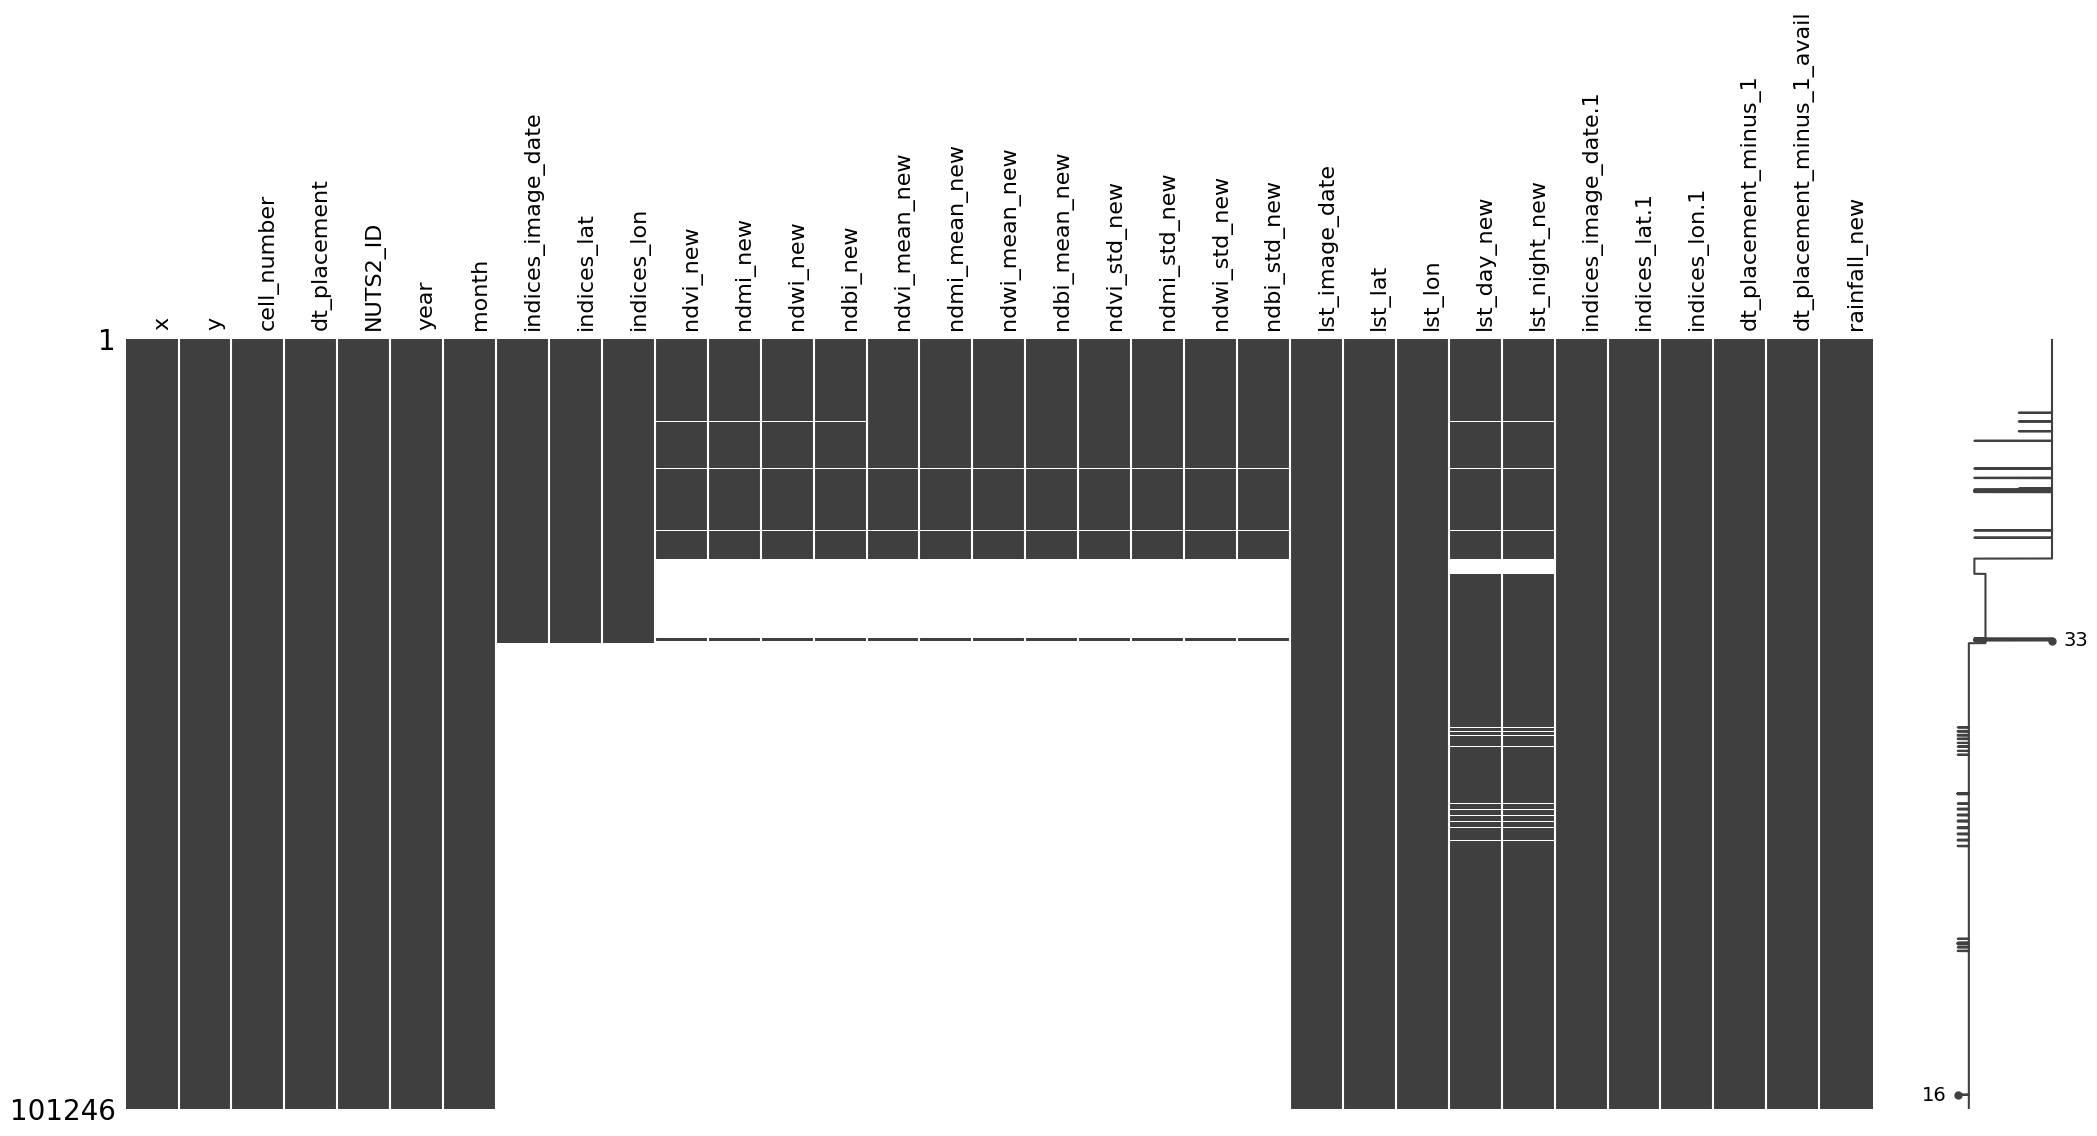

In [66]:
msno.matrix(df, label_rotation=90)

In [67]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)

In [68]:
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)

In [69]:
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [70]:
df['dt_placement']= pd.to_datetime(df['dt_placement'])
df['indices_image_date']= pd.to_datetime(df['indices_image_date'])
df['lst_image_date']= pd.to_datetime(df['lst_image_date'])
df['rainfall_image_date']= pd.to_datetime(df['rainfall_image_date'])

In [71]:
df

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_day,lst_night,rainfall_image_date,rainfall
0,23.65882,41.33542,0,2024-07-02,EL51,2024,7,2024-07-01,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,2024-07-02,14692.0,14711.0,2024-06-02,0.0
1,23.65882,41.33542,0,2024-07-03,EL51,2024,7,2024-07-01,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,2024-07-03,14745.0,14365.0,2024-06-02,0.0
2,23.65882,41.33542,0,2024-07-04,EL51,2024,7,2024-07-01,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,2024-07-04,14745.0,14330.0,2024-06-02,0.0
3,23.65882,41.33542,0,2024-07-05,EL51,2024,7,2024-07-01,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,2024-07-05,14845.0,14341.0,2024-06-02,0.0
4,23.65882,41.33542,0,2024-07-06,EL51,2024,7,2024-07-06,0.673732,0.254694,-0.571299,-0.254694,0.680970,0.274279,-0.577182,-0.274279,0.079766,0.062001,0.057825,0.062001,2024-07-06,14955.0,14534.0,2024-06-02,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101241,26.58397,41.49712,3261,2024-08-01,EL51,2024,8,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-08-01,15529.0,14742.0,2024-06-02,0.0
101242,26.60756,41.35339,3262,2024-08-01,EL51,2024,8,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-08-01,15683.0,14799.0,2024-06-02,0.0
101243,26.60756,41.37135,3263,2024-08-01,EL51,2024,8,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-08-01,15651.0,14801.0,2024-06-02,0.0
101244,26.60756,41.38932,3264,2024-08-01,EL51,2024,8,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-08-01,15651.0,14759.0,2024-06-02,0.0


<Axes: >

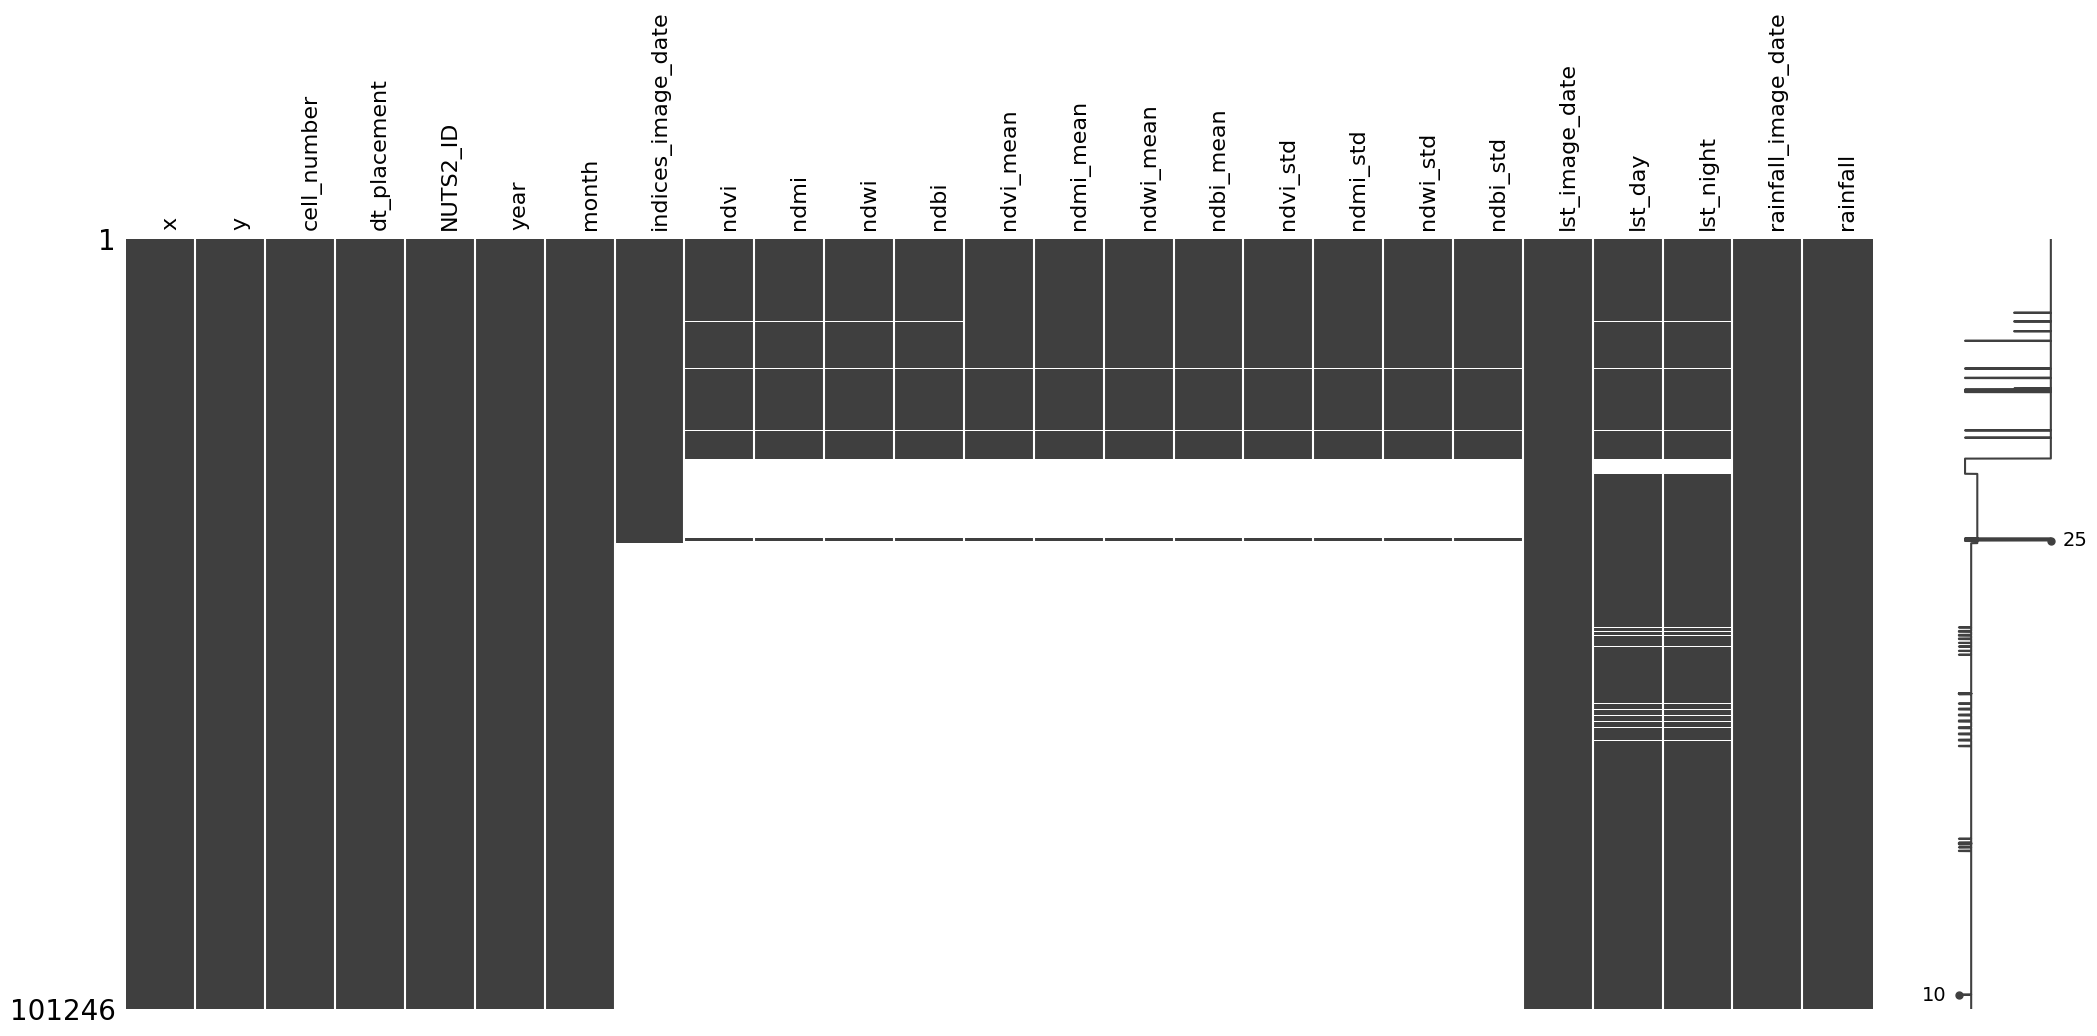

In [72]:
msno.matrix(df, label_rotation=90)

In [73]:
df2 = df.copy()

In [74]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

<Axes: >

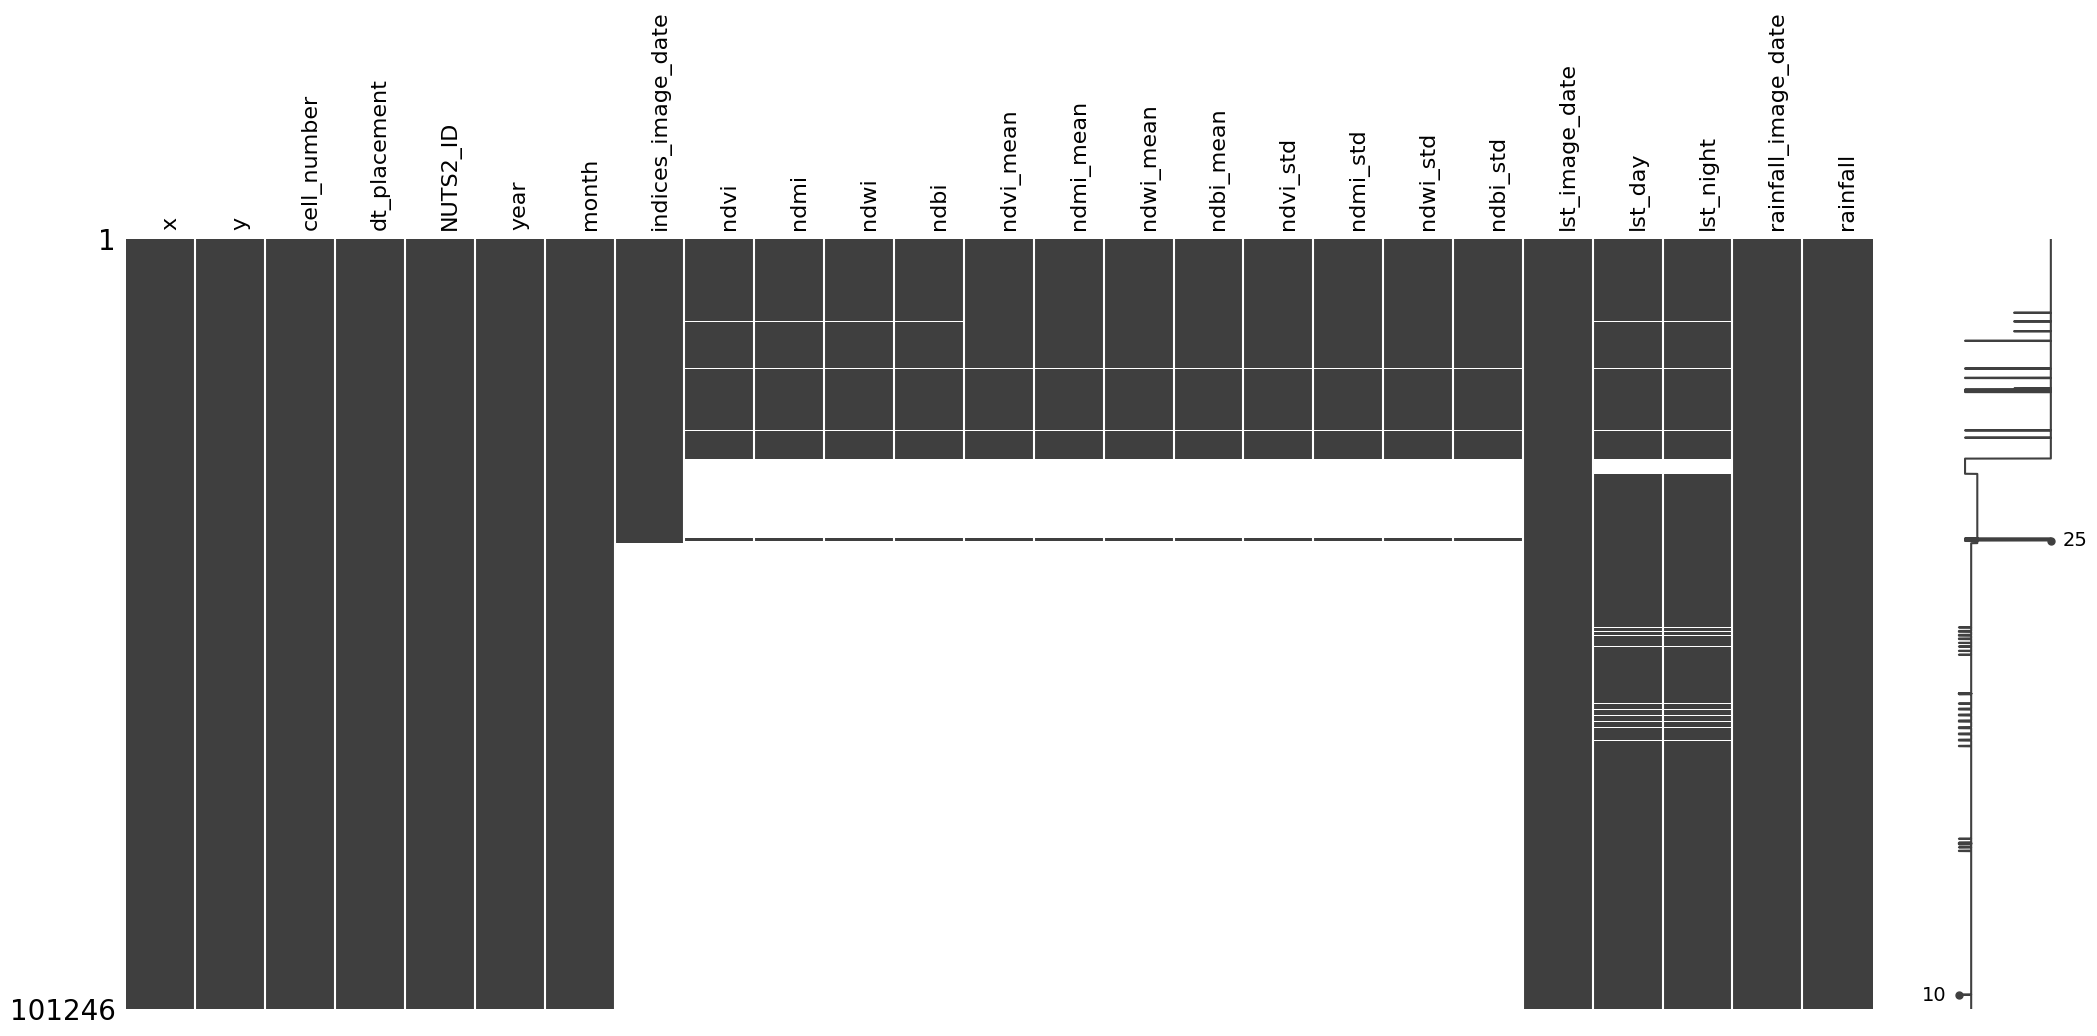

In [75]:
msno.matrix(df, label_rotation=90)

In [76]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
7,indices_image_date,60.4923
8,ndvi,75.2257
9,ndmi,75.2257
10,ndwi,75.2257
11,ndbi,75.2257
12,ndvi_mean,75.1457
13,ndmi_mean,75.1457
14,ndwi_mean,75.1457
15,ndbi_mean,75.1457
16,ndvi_std,75.1457


In [77]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [78]:
df2.reset_index(drop=True, inplace=True)

In [79]:
df2

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,23.65882,41.33542,0,2024-07-02,EL51,2024,7,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,14692.0,14711.0,NaN
1,23.65882,41.33542,0,2024-07-03,EL51,2024,7,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,14745.0,14365.0,NaN
2,23.65882,41.33542,0,2024-07-04,EL51,2024,7,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,14745.0,14330.0,NaN
3,23.65882,41.33542,0,2024-07-05,EL51,2024,7,0.673732,0.254694,-0.571299,-0.254694,0.674435,0.251169,-0.575827,-0.251169,0.051436,0.035251,0.038902,0.035251,14845.0,14341.0,NaN
4,23.65882,41.33542,0,2024-07-06,EL51,2024,7,0.673732,0.254694,-0.571299,-0.254694,0.680970,0.274279,-0.577182,-0.274279,0.079766,0.062001,0.057825,0.062001,14955.0,14534.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101241,26.58397,41.49712,3261,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15529.0,14742.0,NaN
101242,26.60756,41.35339,3262,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15683.0,14799.0,NaN
101243,26.60756,41.37135,3263,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15651.0,14801.0,NaN
101244,26.60756,41.38932,3264,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15651.0,14759.0,NaN


In [80]:
df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding='utf-8')